# EfficientNet-B0 Final-Layer Native CAM

This is the fixed EfficientNet-B0 training notebook for KL grading. It uses one
configuration only: ImageNet-pretrained EfficientNet-B0, a final 12x12 five-map
native-CAM head, cross-entropy, laterality normalization, full inverse-frequency
sampling, and staged unfreezing. The five logits are exactly the spatial means of
the five class maps, so prediction and explanation use the same head.

YOLO is not run here because the Kaggle images are already knee crops. The test
split is created only after validation selects the checkpoint.


## Execution

Run every cell from top to bottom without skipping. The notebook creates a unique
UTC-timestamped directory, saves the selected checkpoint and all metrics/CAM audit
artifacts to Google Drive, and releases the Colab runtime after completion.

The fixed configuration is safe for a 15-16 GiB GPU: physical batch size 24 with
two-step gradient accumulation gives an effective batch size of 48. Automatic
mixed precision, four persistent data workers, pinned memory, cuDNN benchmarking,
and TF32 (where supported) remain enabled. Reduce the physical batch size and
increase accumulation proportionally if a runtime runs out of memory.


In [1]:
import csv
import hashlib
import json
import random
import subprocess
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import tqdm
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    precision_recall_fscore_support,
    recall_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Not running in Colab; Drive mount skipped.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

SEED = 42
ARCHITECTURE = "efficientnet_b0_final_native_cam_ce"
BATCH_SIZE = 24
ACCUMULATION_STEPS = 2
EFFECTIVE_BATCH_SIZE = BATCH_SIZE * ACCUMULATION_STEPS
NUM_WORKERS = 4

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

dataset_zip = Path(
    "/content/drive/MyDrive/Datasets/kaggle_knee_osteoarthritis.zip"
)
if dataset_zip.exists():
    subprocess.run(
        ["unzip", "-q", "-o", str(dataset_zip), "-d", "/content/Datasets"],
        check=True,
    )

DATASET_ROOT = Path("/content/Datasets/kaggle_knee_osteoarthritis")
RUN_TIMESTAMP = datetime.now(timezone.utc).strftime(
    "%Y-%m-%d_%H-%M-%S_%f_UTC"
)
RUN_DIR = (
    Path("/content/drive/MyDrive/Models/efficientnet_b0_checkpoints")
    / f"{RUN_TIMESTAMP}_{ARCHITECTURE}"
)
RUN_DIR.mkdir(parents=True, exist_ok=False)
print(f"Run directory: {RUN_DIR}")

Mounted at /content/drive
Device: cuda
GPU: Tesla T4
Run directory: /content/drive/MyDrive/Models/efficientnet_b0_checkpoints/2026-07-24_04-45-25_604705_UTC_efficientnet_b0_final_native_cam_ce


## Data Preparation

The completed reference runs contain 5,778 unique training images, 826 unique
validation images, and 1,656 unique test images. Images are deduplicated across
splits. Right knees are mirrored so every input follows the same anatomical
orientation. Training uses mild rotation, brightness/contrast jitter, a small
random erase, and the same full inverse-frequency sampler used by the reference
runs. Validation and test transforms are deterministic.

In [2]:
class SquarePad:
    def __call__(self, image):
        height, width = image.shape[:2]
        side = max(height, width)
        top = (side - height) // 2
        bottom = side - height - top
        left = (side - width) // 2
        right = side - width - left
        return cv2.copyMakeBorder(
            image,
            top,
            bottom,
            left,
            right,
            cv2.BORDER_CONSTANT,
            value=[0, 0, 0],
        )


class CLAHE:
    def __call__(self, image):
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        lightness, channel_a, channel_b = cv2.split(lab)
        lightness = cv2.createCLAHE(
            clipLimit=2.0, tileGridSize=(8, 8)
        ).apply(lightness)
        return cv2.cvtColor(
            cv2.merge((lightness, channel_a, channel_b)),
            cv2.COLOR_LAB2RGB,
        )


train_transform = transforms.Compose([
    SquarePad(),
    CLAHE(),
    transforms.ToPILImage(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.Resize((400, 400)),
    transforms.RandomCrop(384),
    transforms.ToTensor(),
    transforms.RandomErasing(
        p=0.10, scale=(0.02, 0.05), ratio=(0.5, 2.0), value=0
    ),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

evaluation_transform = transforms.Compose([
    SquarePad(),
    CLAHE(),
    transforms.ToPILImage(),
    transforms.Resize((400, 400)),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def file_digest(path):
    digest = hashlib.sha256()
    with open(path, "rb") as image_file:
        for chunk in iter(lambda: image_file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


class KneeDataset(Dataset):
    def __init__(self, split, transform, excluded_hashes=None):
        self.transform = transform
        split_dir = DATASET_ROOT / split
        if not split_dir.is_dir():
            raise FileNotFoundError(f"Dataset split is missing: {split_dir}")

        excluded_hashes = excluded_hashes or set()
        retained_hashes = set()
        self.paths = []
        self.labels = []
        for grade in range(5):
            grade_dir = split_dir / str(grade)
            for path in sorted(grade_dir.iterdir()):
                if path.suffix.lower() not in {".png", ".jpg", ".jpeg"}:
                    continue
                digest = file_digest(path)
                if digest in excluded_hashes or digest in retained_hashes:
                    continue
                retained_hashes.add(digest)
                self.paths.append(str(path))
                self.labels.append(grade)
        self.image_hashes = retained_hashes
        print(f"{split}: {len(self.paths)} unique images")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        image = cv2.imread(path)
        if image is None:
            raise IOError(f"Could not read image: {path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if Path(path).stem.upper().endswith("R"):
            image = np.ascontiguousarray(image[:, ::-1])
        return self.transform(image), self.labels[index], path


In [3]:
train_dataset = KneeDataset("train", train_transform)
validation_dataset = KneeDataset(
    "val", evaluation_transform, train_dataset.image_hashes
)

class_counts = Counter(train_dataset.labels)
sample_weights = [
    1.0 / class_counts[label] for label in train_dataset.labels
]
sampler_generator = torch.Generator().manual_seed(SEED)
balanced_sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator=sampler_generator,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=balanced_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    generator=sampler_generator,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
)
print("Class counts:", dict(sorted(class_counts.items())))
print(
    f"Batches: train={len(train_loader)}, "
    f"validation={len(validation_loader)}"
)

train: 5778 unique images
val: 826 unique images
Class counts: {0: 2286, 1: 1046, 2: 1516, 3: 757, 4: 173}
Batches: train=241, validation=35


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Model: `efficientnet_b0_final_native_cam_ce`

The completed scale runs support B0 for the combined validation objective and
model-size tradeoff. At 384x384, its final TorchVision feature tensor is
`(B, 1280, 12, 12)`. A 1x1 class convolution produces `(B, 5, 12, 12)` maps.
Their global means are exactly the five CE logits.

This single final-layer head follows the native-CAM structure already validated
in the DenseNet and SE-ResNeXt experiments. It avoids the shallow-map dilution
and localization regression observed in the 24x24 multiscale SE-ResNeXt run.

In [4]:
class EfficientNetB0NativeCAM(nn.Module):
    '''EfficientNet-B0 with a faithful final-layer 12x12 native-CAM head.'''

    def __init__(self, pretrained=True):
        super().__init__()
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        network = models.efficientnet_b0(weights=weights)
        self.features = network.features
        self.class_conv = nn.Conv2d(1280, 5, kernel_size=1)

    def head_parameters(self):
        return self.class_conv.parameters()

    def class_maps(self, images):
        return self.class_conv(self.features(images))

    def forward(self, images):
        return self.class_maps(images).mean(dim=(2, 3))

    def native_cam(self, images, class_indices=None):
        with torch.no_grad():
            maps = self.class_maps(images)
            logits = maps.mean(dim=(2, 3))
            if class_indices is None:
                class_indices = logits.argmax(dim=1)
            class_indices = torch.as_tensor(
                class_indices, device=images.device, dtype=torch.long
            ).reshape(-1)
            selected = maps[
                torch.arange(images.size(0), device=images.device),
                class_indices,
            ]
            selected = F.relu(selected).unsqueeze(1)
            selected = F.interpolate(
                selected,
                size=images.shape[-2:],
                mode="bilinear",
                align_corners=False,
            ).squeeze(1)
            maxima = selected.flatten(1).amax(1).clamp_min(1e-8)
            selected = selected / maxima[:, None, None]
        return selected, logits

    def freeze_backbone(self):
        for parameter in self.features.parameters():
            parameter.requires_grad = False
        for parameter in self.class_conv.parameters():
            parameter.requires_grad = True

    def unfreeze_final_stages(self):
        for parameter in self.parameters():
            parameter.requires_grad = False
        for block in self.features[6:]:
            for parameter in block.parameters():
                parameter.requires_grad = True
        for parameter in self.class_conv.parameters():
            parameter.requires_grad = True

    def unfreeze_all(self):
        for parameter in self.parameters():
            parameter.requires_grad = True

## Training and Validation

Training uses the same three stages as the successful reference configuration:
five head-only epochs, fifteen final-stage epochs, and ten full fine-tuning
epochs. The raw model is evaluated after every epoch and selected using the same
validation composite of QWK, macro F1/recall, Grade 1 recall, AP, and AUC.

EMA is intentionally excluded. The previous SE-ResNeXt run showed that decay
`0.999` retained too much stage-start state and had not converged by epoch 30.
Batch-normalization statistics in frozen backbone blocks also remain fixed;
otherwise a nominally frozen ImageNet backbone would still drift during warm-up.
The fixed test split is not used for optimization or checkpoint selection.

In [5]:
def calculate_metrics(labels, predictions, probabilities):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    probabilities = np.asarray(probabilities)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        labels=[0, 1, 2, 3, 4],
        average="macro",
        zero_division=0,
    )
    one_hot = np.eye(5)[labels]
    metrics = {
        "accuracy": float(accuracy_score(labels, predictions)),
        "qwk": float(cohen_kappa_score(labels, predictions, weights="quadratic")),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
        "grade1_recall": float(
            recall_score(labels == 1, predictions == 1, zero_division=0)
        ),
        "macro_ap": float(
            average_precision_score(one_hot, probabilities, average="macro")
        ),
        "macro_auc": float(
            roc_auc_score(one_hot, probabilities, average="macro")
        ),
    }
    metrics["selection_score"] = float(
        0.40 * metrics["qwk"]
        + 0.20 * metrics["macro_f1"]
        + 0.10 * metrics["macro_recall"]
        + 0.10 * metrics["grade1_recall"]
        + 0.15 * metrics["macro_ap"]
        + 0.05 * metrics["macro_auc"]
    )
    return metrics


def keep_frozen_batch_norm_eval(model):
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d) and not any(
            parameter.requires_grad for parameter in module.parameters()
        ):
            module.eval()


def train_one_epoch(model, loader, optimizer, scaler, description):
    model.train()
    keep_frozen_batch_norm_eval(model)
    running_loss = 0.0
    number_of_batches = len(loader)
    optimizer.zero_grad(set_to_none=True)
    for batch_index, (images, labels, _) in enumerate(
        tqdm.tqdm(loader, desc=description, leave=False)
    ):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        accumulation_group_start = (
            batch_index // ACCUMULATION_STEPS
        ) * ACCUMULATION_STEPS
        accumulation_group_size = min(
            ACCUMULATION_STEPS,
            number_of_batches - accumulation_group_start,
        )
        with torch.amp.autocast(
            device_type=device.type,
            enabled=device.type == "cuda",
        ):
            loss = F.cross_entropy(model(images), labels)
            backward_loss = loss / accumulation_group_size
        scaler.scale(backward_loss).backward()

        is_accumulation_boundary = (
            (batch_index + 1) % ACCUMULATION_STEPS == 0
            or batch_index + 1 == number_of_batches
        )
        if is_accumulation_boundary:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
        running_loss += loss.item() * labels.size(0)
    return running_loss / len(loader.dataset)


def evaluate(model, loader, description):
    model.eval()
    labels_all, predictions_all, probabilities_all, paths_all = [], [], [], []
    total_loss = 0.0
    with torch.no_grad():
        for images, labels, paths in tqdm.tqdm(loader, desc=description, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            probabilities = F.softmax(logits.float(), dim=1)
            total_loss += F.cross_entropy(logits, labels).item() * labels.size(0)
            labels_all.extend(labels.cpu().numpy())
            predictions_all.extend(probabilities.argmax(1).cpu().numpy())
            probabilities_all.extend(probabilities.cpu().numpy())
            paths_all.extend(paths)
    metrics = calculate_metrics(
        labels_all, predictions_all, probabilities_all
    )
    metrics["loss"] = total_loss / len(loader.dataset)
    return (
        metrics,
        np.asarray(labels_all),
        np.asarray(predictions_all),
        np.asarray(probabilities_all),
        paths_all,
    )


def load_checkpoint(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)

In [6]:
model = EfficientNetB0NativeCAM(pretrained=True).to(device)
scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
stage2_path = RUN_DIR / "stage2_best_model.pth"
best_path = RUN_DIR / "best_model.pth"
last_path = RUN_DIR / "last_model.pth"
history = []
best_stage2_score = -float("inf")
best_selection_score = -float("inf")
global_epoch = 0

for stage_name, stage_epochs in (("warmup", 5), ("coarse", 15), ("finetune", 10)):
    if stage_name == "warmup":
        model.freeze_backbone()
        optimizer = optim.AdamW(
            model.head_parameters(), lr=3e-4, weight_decay=1e-4
        )
        scheduler = None
    elif stage_name == "coarse":
        model.unfreeze_final_stages()
        optimizer = optim.AdamW(
            [
                {
                    "params": [
                        parameter for parameter in model.features.parameters()
                        if parameter.requires_grad
                    ],
                    "lr": 3e-5,
                },
                {"params": model.head_parameters(), "lr": 3e-4},
            ],
            weight_decay=1e-4,
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=15, eta_min=1e-7
        )
    else:
        if not stage2_path.exists():
            raise FileNotFoundError("Stage 2 did not produce a checkpoint.")
        model.load_state_dict(load_checkpoint(stage2_path)["model_state_dict"])
        model.unfreeze_all()
        optimizer = optim.AdamW(
            model.parameters(), lr=1e-5, weight_decay=1e-3
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=10, eta_min=1e-7
        )

    for stage_epoch in range(stage_epochs):
        global_epoch += 1
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scaler,
            f"{stage_name} {stage_epoch + 1}/{stage_epochs}",
        )
        validation_metrics, _, _, _, _ = evaluate(
            model, validation_loader, "VALIDATE"
        )
        history.append({
            "epoch": global_epoch,
            "stage": stage_name,
            "train_loss": train_loss,
            **validation_metrics,
        })
        print(
            f"Epoch {global_epoch:02d} | {stage_name} | "
            f"QWK={validation_metrics['qwk']:.4f} | "
            f"F1={validation_metrics['macro_f1']:.4f} | "
            f"G1R={validation_metrics['grade1_recall']:.4f} | "
            f"AP={validation_metrics['macro_ap']:.4f} | "
            f"selection={validation_metrics['selection_score']:.4f}"
        )
        if scheduler is not None:
            scheduler.step()

        candidate_payload = {
            "model_state_dict": model.state_dict(),
            "epoch": global_epoch,
            "stage": stage_name,
            "architecture": ARCHITECTURE,
            "model_name": "efficientnet_b0",
            "loss_type": "ce",
            "validation_metrics": validation_metrics,
            "history": history,
            "run_timestamp": RUN_TIMESTAMP,
            "experimental_config": {
                "input_resize": 400,
                "input_crop": 384,
                "physical_batch_size": BATCH_SIZE,
                "gradient_accumulation_steps": ACCUMULATION_STEPS,
                "effective_batch_size": EFFECTIVE_BATCH_SIZE,
                "num_workers": NUM_WORKERS,
                "sampler": "full_inverse_frequency",
                "canonicalize_laterality": True,
                "stage_epochs": [5, 15, 10],
                "learning_rates": [3e-4, 3e-5, 1e-5],
                "native_cam_source_resolution": 12,
                "native_cam_feature_stage": 8,
                "ema": False,
            },
        }
        if (
            stage_name == "coarse"
            and validation_metrics["selection_score"] > best_stage2_score
        ):
            best_stage2_score = validation_metrics["selection_score"]
            torch.save(candidate_payload, stage2_path)
        if (
            stage_name in {"coarse", "finetune"}
            and validation_metrics["selection_score"] > best_selection_score
        ):
            best_selection_score = validation_metrics["selection_score"]
            torch.save(candidate_payload, best_path)
        torch.save(candidate_payload, last_path)

if not best_path.exists():
    raise RuntimeError("Training finished without a final checkpoint.")
with open(RUN_DIR / "epoch_metrics.csv", "w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=history[0].keys())
    writer.writeheader()
    writer.writerows(history)
print(f"Selected checkpoint: {best_path}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 205MB/s]
warmup 1/5:   0%|          | 0/241 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 01 | warmup | QWK=0.4977 | F1=0.3066 | G1R=0.4641 | AP=0.3986 | selection=0.4459


Epoch 02 | warmup | QWK=0.4856 | F1=0.2362 | G1R=0.0261 | AP=0.4012 | selection=0.3813


Epoch 03 | warmup | QWK=0.5230 | F1=0.2901 | G1R=0.4183 | AP=0.4225 | selection=0.4538


...

Epoch 26 | finetune | QWK=0.7654 | F1=0.6228 | G1R=0.2810 | AP=0.6845 | selection=0.6680


Epoch 27 | finetune | QWK=0.7724 | F1=0.6262 | G1R=0.2941 | AP=0.6856 | selection=0.6734


Epoch 28 | finetune | QWK=0.7778 | F1=0.6346 | G1R=0.2876 | AP=0.6908 | selection=0.6787


Epoch 29 | finetune | QWK=0.7798 | F1=0.6342 | G1R=0.2876 | AP=0.6917 | selection=0.6793


Epoch 30 | finetune | QWK=0.7719 | F1=0.6159 | G1R=0.2680 | AP=0.6884 | selection=0.6688
Selected checkpoint: /content/drive/MyDrive/Models/efficientnet_b0_checkpoints/2026-07-24_04-45-25_604705_UTC_efficientnet_b0_final_native_cam_ce/best_model.pth


## Selected Validation and Test Evaluation

The strongest coarse-or-finetune checkpoint is re-evaluated on validation so its per-image
probabilities and SHA-256 keys can be paired with DenseNet and SE-ResNeXt in a
later two-versus-three-model ensemble ablation. The test split is evaluated
once for documentation and never influences checkpoint selection or the
candidate gate.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


test: 1656 unique images


TEST:   0%|          | 0/69 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


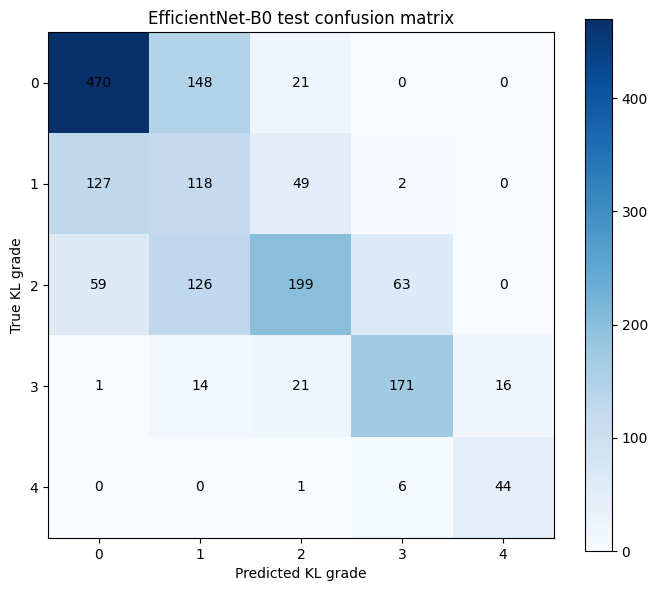

{
  "accuracy": 0.605072463768116,
  "qwk": 0.799221295645576,
  "macro_precision": 0.625961400414905,
  "macro_recall": 0.6417848606872384,
  "macro_f1": 0.6258126069744218,
  "grade1_recall": 0.39864864864864863,
  "macro_ap": 0.6816657218202132,
  "macro_auc": 0.8722978228944976,
  "selection_score": 0.6947591400044604,
  "loss": 0.8842534820238749
}
              precision    recall  f1-score   support

     Grade 0       0.72      0.74      0.73       639
     Grade 1       0.29      0.40      0.34       296
     Grade 2       0.68      0.45      0.54       447
     Grade 3       0.71      0.77      0.74       223
     Grade 4       0.73      0.86      0.79        51

    accuracy                           0.61      1656
   macro avg       0.63      0.64      0.63      1656
weighted avg       0.63      0.61      0.61      1656



In [7]:
best_checkpoint = load_checkpoint(best_path)
model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()

selected_validation_metrics, val_true, val_predicted, val_probabilities, val_paths = (
    evaluate(model, validation_loader, "SELECTED VALIDATION")
)

test_dataset = KneeDataset(
    "test",
    evaluation_transform,
    train_dataset.image_hashes | validation_dataset.image_hashes,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
)
test_metrics, test_true, test_predicted, test_probabilities, test_paths = evaluate(
    model, test_loader, "TEST"
)


def save_predictions(path, image_paths, true_labels, predictions, probabilities):
    rows = []
    for image_path, true_grade, predicted_grade, probability in zip(
        image_paths, true_labels, predictions, probabilities
    ):
        rows.append({
            "image_sha256": file_digest(image_path),
            "path": image_path,
            "true_grade": int(true_grade),
            "predicted_grade": int(predicted_grade),
            **{
                f"grade_{grade}_probability": float(probability[grade])
                for grade in range(5)
            },
        })
    with open(path, "w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=rows[0].keys())
        writer.writeheader()
        writer.writerows(rows)


save_predictions(
    RUN_DIR / "validation_predictions.csv",
    val_paths,
    val_true,
    val_predicted,
    val_probabilities,
)
save_predictions(
    RUN_DIR / "test_predictions.csv",
    test_paths,
    test_true,
    test_predicted,
    test_probabilities,
)
with open(RUN_DIR / "test_metrics.json", "w") as handle:
    json.dump(test_metrics, handle, indent=2)

matrix = confusion_matrix(test_true, test_predicted, labels=[0, 1, 2, 3, 4])
figure, axis = plt.subplots(figsize=(7, 6))
image = axis.imshow(matrix, cmap="Blues")
for row in range(5):
    for column in range(5):
        axis.text(column, row, matrix[row, column], ha="center", va="center")
axis.set(
    title="EfficientNet-B0 test confusion matrix",
    xlabel="Predicted KL grade",
    ylabel="True KL grade",
    xticks=range(5),
    yticks=range(5),
)
figure.colorbar(image, ax=axis)
figure.tight_layout()
figure.savefig(RUN_DIR / "test_confusion_matrix.png", dpi=180)
plt.show()

print(json.dumps(test_metrics, indent=2))
print(classification_report(
    test_true,
    test_predicted,
    labels=[0, 1, 2, 3, 4],
    target_names=[f"Grade {grade}" for grade in range(5)],
    zero_division=0,
))

## Native-CAM Localization and Occlusion Audit

The audit samples up to 50 validation cases from every grade. It measures broad
joint energy, border energy, lower-tibia energy, and peak location for both the
predicted and true classes. For predicted-class CAM faithfulness, each image is
divided into a 4x4 grid and all 16 mean-filled occlusions are evaluated in one
batch. Positive correlation between CAM patch energy and predicted-class
probability drop indicates that hotter regions affect the model output.

The source class maps are 12x12. These measurements audit model behavior; they
are not expert lesion segmentations.

EFFICIENTNET NATIVE CAM AUDIT: 100%|██████████| 227/227 [00:24<00:00,  9.45it/s]


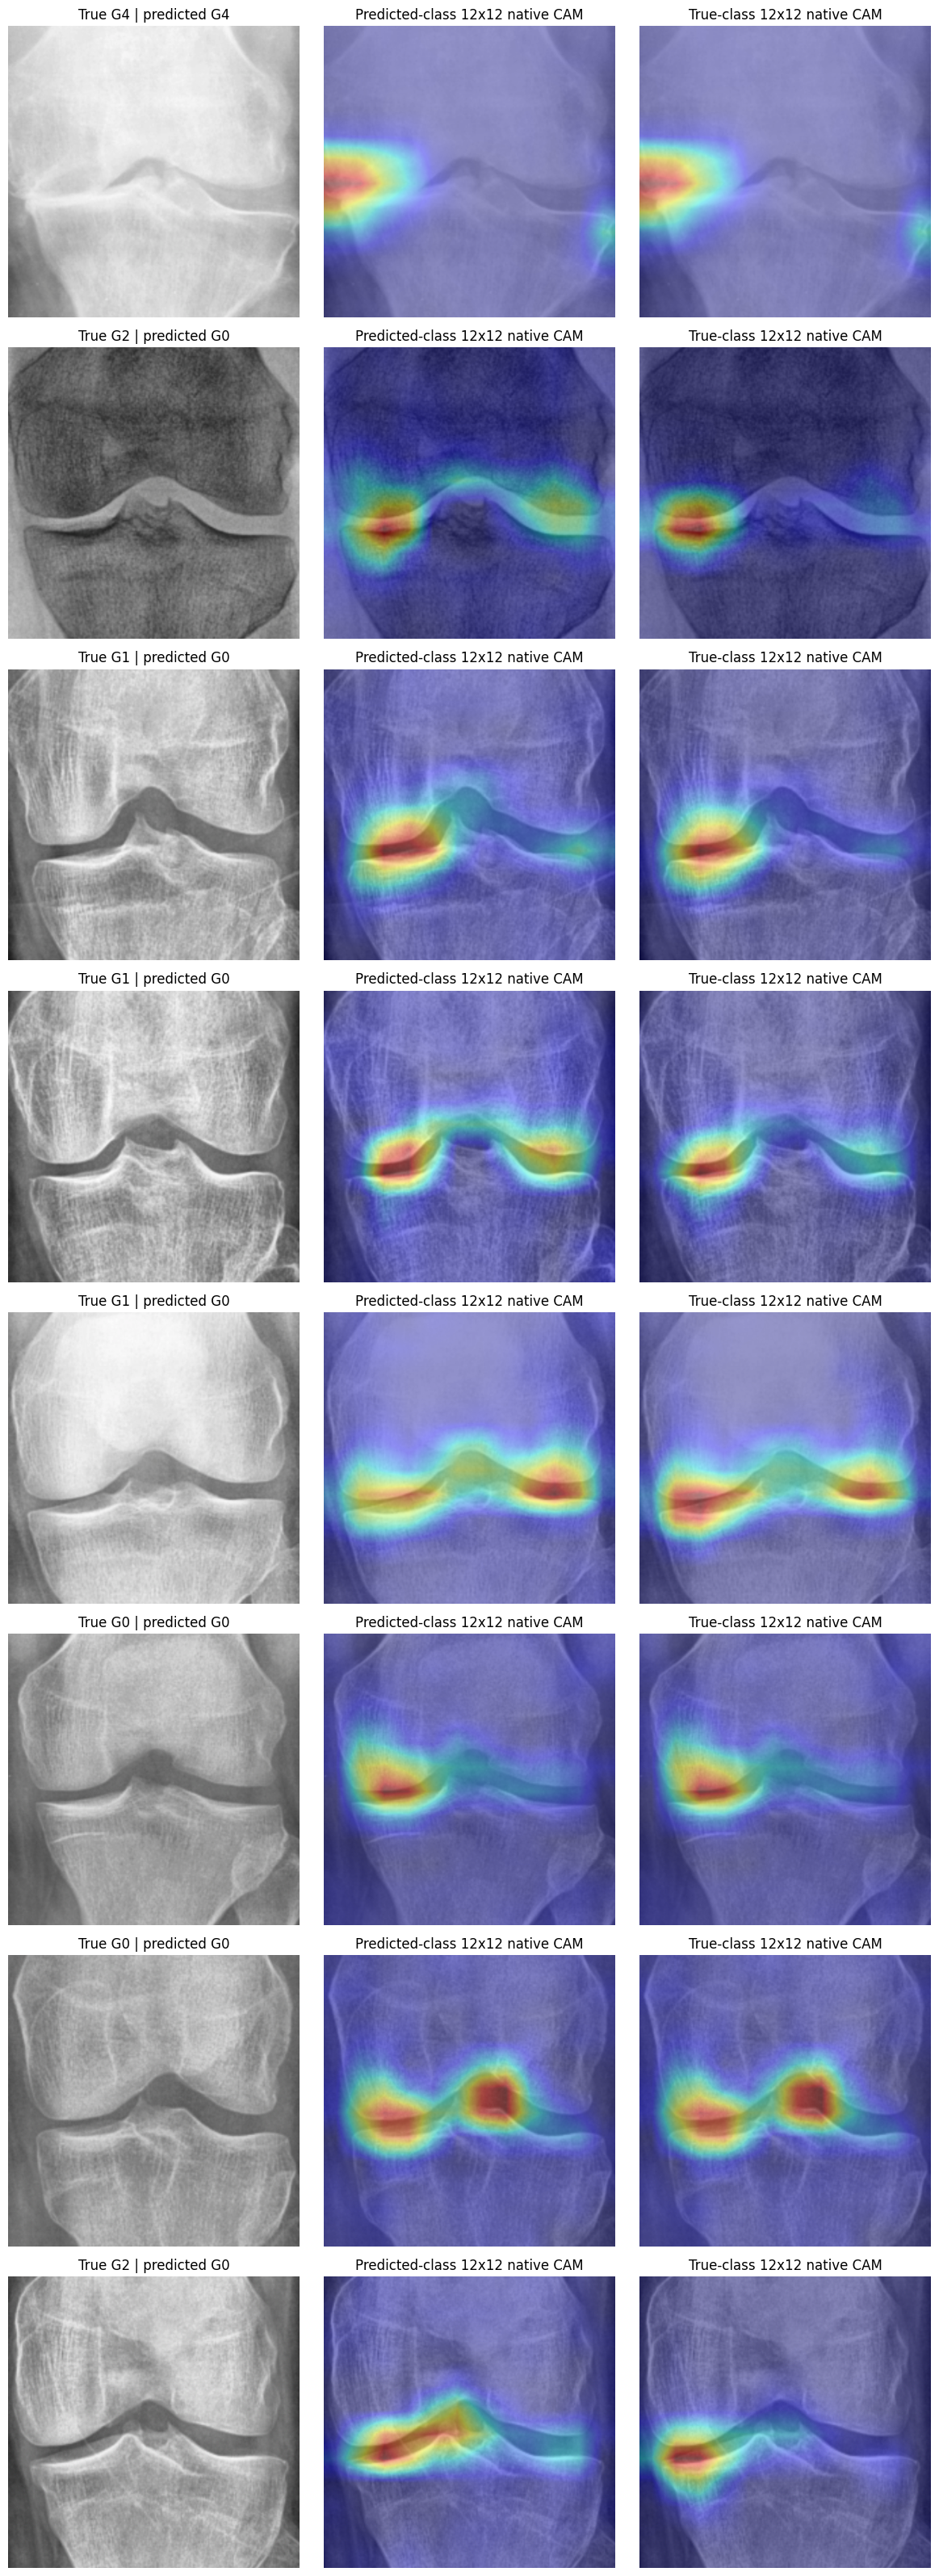

{
  "audited_cases": 227,
  "source_resolution": 12,
  "joint_energy": 0.8279616155485224,
  "border_energy": 0.1080459798832963,
  "lower_tibia_energy": 0.07971512992557149,
  "peak_inside_joint_rate": 0.9955947136563876,
  "occlusion_cam_correlation": 0.617208206631822,
  "top_cam_occlusion_drop": 0.09849593543861931
}


In [8]:
def cam_geometry(cam):
    height, width = cam.shape
    joint = np.zeros((height, width), dtype=bool)
    joint[
        int(0.28 * height):int(0.72 * height),
        int(0.06 * width):int(0.94 * width),
    ] = True
    border = np.ones((height, width), dtype=bool)
    border[
        int(0.08 * height):int(0.92 * height),
        int(0.08 * width):int(0.92 * width),
    ] = False
    lower_tibia = np.zeros((height, width), dtype=bool)
    lower_tibia[int(0.72 * height):, :] = True
    total = float(cam.sum()) + 1e-8
    peak = np.unravel_index(np.argmax(cam), cam.shape)
    return {
        "joint_energy": float(cam[joint].sum()) / total,
        "border_energy": float(cam[border].sum()) / total,
        "lower_tibia_energy": float(cam[lower_tibia].sum()) / total,
        "peak_inside_joint": int(joint[peak]),
    }


@torch.no_grad()
def occlusion_faithfulness(model, image, predicted_class, cam, grid_size=4):
    baseline_probability = F.softmax(model(image[None]), dim=1)[
        0, predicted_class
    ]
    height, width = image.shape[-2:]
    patch_height = height // grid_size
    patch_width = width // grid_size
    occluded = []
    cam_energy = []
    for row in range(grid_size):
        for column in range(grid_size):
            y0 = row * patch_height
            y1 = height if row == grid_size - 1 else (row + 1) * patch_height
            x0 = column * patch_width
            x1 = width if column == grid_size - 1 else (column + 1) * patch_width
            variant = image.clone()
            variant[:, y0:y1, x0:x1] = 0.0
            occluded.append(variant)
            cam_energy.append(float(cam[y0:y1, x0:x1].sum()))
    variants = torch.stack(occluded).to(device)
    probabilities = F.softmax(model(variants), dim=1)[:, predicted_class]
    drops = (baseline_probability - probabilities).cpu().numpy()
    cam_energy = np.asarray(cam_energy)
    if np.std(cam_energy) < 1e-8 or np.std(drops) < 1e-8:
        correlation = 0.0
    else:
        correlation = float(np.corrcoef(cam_energy, drops)[0, 1])
    top_count = max(1, len(cam_energy) // 4)
    top_indices = np.argsort(cam_energy)[-top_count:]
    return {
        "occlusion_cam_correlation": correlation,
        "top_cam_occlusion_drop": float(np.mean(drops[top_indices])),
    }


rng = np.random.default_rng(SEED)
audit_indices = []
labels_array = np.asarray(validation_dataset.labels)
for grade in range(5):
    grade_indices = np.flatnonzero(labels_array == grade)
    rng.shuffle(grade_indices)
    audit_indices.extend(grade_indices[:min(50, len(grade_indices))].tolist())

cam_rows = []
cached_maps = {}
for index in tqdm.tqdm(audit_indices, desc="EFFICIENTNET NATIVE CAM AUDIT"):
    tensor, true_grade, path = validation_dataset[index]
    batch = tensor[None].to(device)
    with torch.no_grad():
        logits = model(batch)
        predicted_grade = int(logits.argmax(1).item())
    predicted_cam, _ = model.native_cam(batch, [predicted_grade])
    true_cam, _ = model.native_cam(batch, [int(true_grade)])
    predicted_cam = predicted_cam[0].cpu().numpy()
    true_cam = true_cam[0].cpu().numpy()
    row = {
        "dataset_index": index,
        "path": path,
        "true_grade": int(true_grade),
        "predicted_grade": predicted_grade,
        **{
            f"predicted_{key}": value
            for key, value in cam_geometry(predicted_cam).items()
        },
        **{
            f"true_{key}": value
            for key, value in cam_geometry(true_cam).items()
        },
        **occlusion_faithfulness(
            model, tensor.to(device), predicted_grade, predicted_cam
        ),
    }
    cam_rows.append(row)
    cached_maps[index] = (tensor, predicted_cam, true_cam)

with open(RUN_DIR / "native_cam_audit.csv", "w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=cam_rows[0].keys())
    writer.writeheader()
    writer.writerows(cam_rows)

cam_summary = {
    "audited_cases": len(cam_rows),
    "source_resolution": 12,
    "joint_energy": float(np.mean([
        row["predicted_joint_energy"] for row in cam_rows
    ])),
    "border_energy": float(np.mean([
        row["predicted_border_energy"] for row in cam_rows
    ])),
    "lower_tibia_energy": float(np.mean([
        row["predicted_lower_tibia_energy"] for row in cam_rows
    ])),
    "peak_inside_joint_rate": float(np.mean([
        row["predicted_peak_inside_joint"] for row in cam_rows
    ])),
    "occlusion_cam_correlation": float(np.mean([
        row["occlusion_cam_correlation"] for row in cam_rows
    ])),
    "top_cam_occlusion_drop": float(np.mean([
        row["top_cam_occlusion_drop"] for row in cam_rows
    ])),
}
with open(RUN_DIR / "native_cam_summary.json", "w") as handle:
    json.dump(cam_summary, handle, indent=2)

worst_cases = sorted(
    cam_rows,
    key=lambda row: (
        1 - row["predicted_peak_inside_joint"]
        + row["predicted_border_energy"]
        + row["predicted_lower_tibia_energy"]
        - max(0.0, row["occlusion_cam_correlation"])
    ),
    reverse=True,
)[:8]
mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
figure, axes = plt.subplots(len(worst_cases), 3, figsize=(12, 4 * len(worst_cases)))
for row_index, row in enumerate(worst_cases):
    tensor, predicted_cam, true_cam = cached_maps[row["dataset_index"]]
    display_image = (
        (tensor.cpu() * std + mean)
        .clamp(0, 1)
        .permute(1, 2, 0)
        .numpy()
    )
    axes[row_index, 0].imshow(display_image)
    axes[row_index, 0].set_title(
        f"True G{row['true_grade']} | predicted G{row['predicted_grade']}"
    )
    axes[row_index, 1].imshow(display_image)
    axes[row_index, 1].imshow(predicted_cam, cmap="jet", alpha=0.40)
    axes[row_index, 1].set_title("Predicted-class 12x12 native CAM")
    axes[row_index, 2].imshow(display_image)
    axes[row_index, 2].imshow(true_cam, cmap="jet", alpha=0.40)
    axes[row_index, 2].set_title("True-class 12x12 native CAM")
    for axis in axes[row_index]:
        axis.axis("off")
figure.tight_layout()
figure.savefig(RUN_DIR / "native_cam_worst_cases.png", dpi=180)
plt.show()
print(json.dumps(cam_summary, indent=2))

## Reproducible Run Report

The final cell records the exact timestamp, fixed configuration, selected epoch,
validation and test metrics, and quantitative native-CAM audit. Test results are
reported but never used to select the checkpoint.


In [9]:
validation_metrics = best_checkpoint["validation_metrics"]

manifest = {
    "run_timestamp": RUN_TIMESTAMP,
    "run_directory": str(RUN_DIR),
    "model_name": "efficientnet_b0",
    "architecture": ARCHITECTURE,
    "loss": "cross_entropy",
    "ema": False,
    "input_resize": 400,
    "input_crop": 384,
    "physical_batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": ACCUMULATION_STEPS,
    "effective_batch_size": EFFECTIVE_BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "sampler": "full_inverse_frequency",
    "canonicalize_laterality": True,
    "stages": [
        {"name": "warmup", "epochs": 5, "learning_rate": 3e-4},
        {
            "name": "coarse",
            "epochs": 15,
            "backbone_learning_rate": 3e-5,
            "head_learning_rate": 3e-4,
        },
        {"name": "finetune", "epochs": 10, "learning_rate": 1e-5},
    ],
    "best_epoch": best_checkpoint["epoch"],
    "validation_metrics": validation_metrics,
    "test_metrics": test_metrics,
    "native_cam_summary": cam_summary,
    "selected_checkpoint": str(best_path),
}
with open(RUN_DIR / "run_manifest.json", "w") as handle:
    json.dump(manifest, handle, indent=2)
(RUN_DIR / "SELECTED_CHECKPOINT.txt").write_text(str(best_path) + "\n")

report = f'''# EfficientNet-B0 Final-Layer Native-CAM Report

| Field | Value |
| --- | --- |
| Exact UTC run timestamp | {RUN_TIMESTAMP} |
| Architecture | `{ARCHITECTURE}` |
| Native-CAM source | Final 12x12 class maps |
| EMA | Disabled |
| Loss | Cross-entropy |
| Input | Resize 400, center/random crop 384 |
| Physical batch size | {BATCH_SIZE} |
| Gradient accumulation | {ACCUMULATION_STEPS} steps |
| Effective batch size | {EFFECTIVE_BATCH_SIZE} |
| Data workers | {NUM_WORKERS} |
| Sampler | Full inverse-frequency |
| Best epoch | {best_checkpoint['epoch']} |
| Selected checkpoint | `{best_path}` |

## Validation Selection Metrics

| Accuracy | QWK | Macro Precision | Macro Recall | Macro F1 | Grade 1 Recall | AP | AUC | Selection |
| ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| {validation_metrics['accuracy']:.4f} | {validation_metrics['qwk']:.4f} | {validation_metrics['macro_precision']:.4f} | {validation_metrics['macro_recall']:.4f} | {validation_metrics['macro_f1']:.4f} | {validation_metrics['grade1_recall']:.4f} | {validation_metrics['macro_ap']:.4f} | {validation_metrics['macro_auc']:.4f} | {validation_metrics['selection_score']:.4f} |

## Test Metrics (Not Used for Selection)

| Accuracy | QWK | Macro Precision | Macro Recall | Macro F1 | Grade 1 Recall | AP | AUC |
| ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| {test_metrics['accuracy']:.4f} | {test_metrics['qwk']:.4f} | {test_metrics['macro_precision']:.4f} | {test_metrics['macro_recall']:.4f} | {test_metrics['macro_f1']:.4f} | {test_metrics['grade1_recall']:.4f} | {test_metrics['macro_ap']:.4f} | {test_metrics['macro_auc']:.4f} |

## Native-CAM Audit

| Cases | Source | Joint energy | Border energy | Lower-tibia energy | Peak inside | Occlusion correlation | Top-CAM drop |
| ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| {cam_summary['audited_cases']} | {cam_summary['source_resolution']}x{cam_summary['source_resolution']} | {cam_summary['joint_energy']:.4f} | {cam_summary['border_energy']:.4f} | {cam_summary['lower_tibia_energy']:.4f} | {cam_summary['peak_inside_joint_rate']:.4f} | {cam_summary['occlusion_cam_correlation']:.4f} | {cam_summary['top_cam_occlusion_drop']:.4f} |

Checkpoint selection used validation metrics only. The test split was evaluated once
after selection. The native-CAM audit includes up to 50 validation knees per grade
and saves predicted-class and true-class maps for the worst localization cases.
'''
(RUN_DIR / "report.md").write_text(report, encoding="utf-8")
print(report)
print(f"Report: {RUN_DIR / 'report.md'}")
print(f"All artifacts: {RUN_DIR}")


# EfficientNet-B0 Final-Layer Native-CAM Report

| Field | Value |
| --- | --- |
| Exact UTC run timestamp | 2026-07-24_04-45-25_604705_UTC |
| Architecture | `efficientnet_b0_final_native_cam_ce` |
| Native-CAM source | Final 12x12 class maps |
| EMA | Disabled |
| Loss | Cross-entropy |
| Input | Resize 400, center/random crop 384 |
| Physical batch size | 24 |
| Gradient accumulation | 2 steps |
| Effective batch size | 48 |
| Data workers | 4 |
| Sampler | Full inverse-frequency |
| Best epoch | 10 |
| Selected checkpoint | `/content/drive/MyDrive/Models/efficientnet_b0_checkpoints/2026-07-24_04-45-25_604705_UTC_efficientnet_b0_final_native_cam_ce/best_model.pth` |

## Validation Selection Metrics

| Accuracy | QWK | Macro Precision | Macro Recall | Macro F1 | Grade 1 Recall | AP | AUC | Selection |
| ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| 0.6150 | 0.7743 | 0.6279 | 0.6616 | 0.6317 | 0.4771 | 0.6690 | 0.8660 | 0.6936 |

## Test Metrics (Not Used for Select

In [10]:
try:
    from google.colab import runtime
    print("All artifacts saved. Releasing the Colab runtime.")
    runtime.unassign()
except ImportError:
    print("Not running in Colab; runtime release skipped.")


All artifacts saved. Releasing the Colab runtime.
